In [1]:
from scipy.optimize import fsolve
from numpy import sqrt, pi, log10
from units_astro import *
from dustyCPD import Sigma, T_c_approx, mu, Rp, Mp
import numpy as np

def alpha_mag(R,Mpdot,alpha,Bps):
    # This is the magnetic alpha parameter
    Sigma_mag = Sigma(R,Mpdot,alpha)
    Omega = sqrt(G*Mp/R**3)
    c_s = sqrt(Rgas*T_c_approx(R,Mpdot,alpha)/(mu))
    Bp=Bps*(Rp/R)**3
    beta_mag=Sigma_mag*Omega*c_s/sqrt(2*pi)/(Bp**2/(8*pi))
    return 11*beta_mag**(-0.53)



# now we try to fing an alpha that makes alpha_mag=alpha
def alpha_finder(log_10_alpha,R,Mpdot,Bps):
    alpha=10.0**log_10_alpha
    return log_10_alpha-log10(alpha_mag(R,Mpdot,alpha,Bps))


# We calculate the 0 of the function alpha_finder
def alpha_calculator(R,Mpdot,Bps,min_log_alpha=-5):
    logalpha=fsolve(alpha_finder, 5, args=(R, Mpdot, Bps))
    return 10**np.max([logalpha[0], min_log_alpha])

# We calculate the 0 of the function alpha_finder
def alpha_calculator(R,Mpdot,Bps,min_log_alpha=-5):
    # first check R is an array or a number
    if np.isscalar(R):
        R=np.array([R])
        logalpha=fsolve(alpha_finder, 5, args=(R, Mpdot, Bps))
        return 10**np.max(np.array([logalpha[0], min_log_alpha]))
    else:
        length_R=len(R)
        arr_initial_guess=np.full(length_R,5)
        arr_min_log_alpha=np.full(length_R,min_log_alpha)
        logalpha=fsolve(alpha_finder, arr_initial_guess, args=(R, Mpdot, Bps))
        print('logalpha:', logalpha)
        return 10**np.max(np.array([logalpha, arr_min_log_alpha]), axis=0)

Rout (au):  0.11378401832314596


In [2]:
R_array=np.array([0.01*au])
Mpdot=1E-6*Mj/yr
Bps=300 # G
alpha=np.zeros(len(R_array))

alpha_arr=alpha_calculator(R_array, Mpdot, Bps)


logalpha: [-2.10883985]


In [3]:
print(alpha_finder(log10(alpha_arr), R_array, Mpdot, Bps))
print(alpha_arr)
print(alpha_mag(R_array, Mpdot, alpha_arr, Bps))

print(alpha_mag(R_array, Mpdot, alpha_arr, Bps))

[0.]
[0.00778324]
[0.00778324]
[0.00778324]


In [4]:
# now the previous method
def alpha_mag(R,Mpdot,alpha,Bps):
    # This is the magnetic alpha parameter
    Sigma_mag = Sigma(R,Mpdot,alpha)
    Omega = sqrt(G*Mp/R**3)
    c_s = sqrt(Rgas*T_c_approx(R,Mpdot,alpha)/(mu))
    Bp=Bps*(Rp/R)**3
    beta_mag=Sigma_mag*Omega*c_s/sqrt(2*pi)/(Bp**2/(8*pi))
    return 11*beta_mag**(-0.53)


# We calculate the 0 of the function alpha_finder
def alpha_calculator(R,Mpdot,Bps,min_log_alpha=-5):
    logalpha=fsolve(alpha_finder, 5, args=(R, Mpdot, Bps))
    return 10**np.max([logalpha[0], min_log_alpha])


# We calculate the 0 of the function alpha_finder
def alpha_calculator(R,Mpdot,Bps,min_log_alpha=-5):
    logalpha=fsolve(alpha_finder, 5, args=(R, Mpdot, Bps))
    return 10**np.max([logalpha[0], min_log_alpha])


alpha=np.zeros(len(R_array))
for i in range(len(R_array)):
    alpha[i]=alpha_calculator(R_array[i], Mpdot, Bps)   

alpha

array([0.00778324])

In [5]:
alpha

array([0.00778324])

In [6]:
print(alpha)

print(alpha_mag(R_array[0], Mpdot, alpha[0], Bps))

[0.00778324]
0.007783235127749259


In [7]:
alpha_arrays_plot=np.logspace(-5,0,100)
alpha_mag_plot=np.zeros(len(alpha_arrays_plot))
for i in range(len(alpha_arrays_plot)):
    alpha_mag_plot[i]=alpha_mag(R_array[0], Mpdot, alpha_arrays_plot[i], Bps)


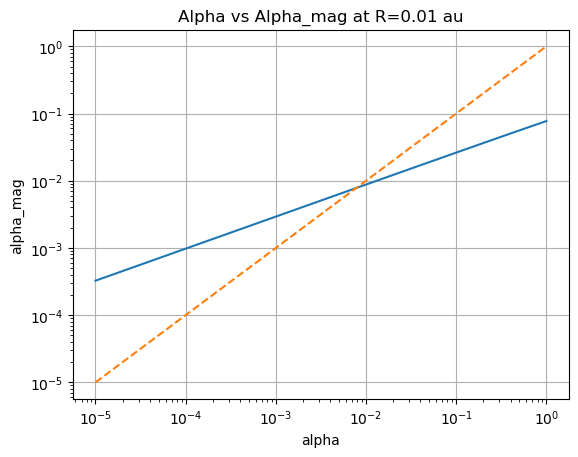

In [8]:
import matplotlib.pyplot as plt
plt.loglog(alpha_arrays_plot, alpha_mag_plot)
plt.loglog(alpha_arrays_plot, alpha_arrays_plot, '--')
plt.xlabel('alpha')
plt.ylabel('alpha_mag')
plt.title('Alpha vs Alpha_mag at R='+str(R_array[0]/au)+' au')
plt.grid()
plt.show()

In [ ]:
arr=np.array([1,2,3,4,5]) # I want a new matrix with the same values in each column
matrix=arr[:, np.newaxis].repeat(3, axis=1).transpose()
print(matrix)

[[1 2 3 4 5]
 [1 2 3 4 5]
 [1 2 3 4 5]]
